In [9]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

In [10]:
# loading in data
def load_training_data(data_dir="data"):
    X_raw = np.load(os.path.join(data_dir, "train_tabular.npy"), allow_pickle=True)
    y = np.load(os.path.join(data_dir, "train_labels.npy"))
    ids = np.load(os.path.join(data_dir, "train_ids.npy"), allow_pickle=True)
    return X_raw, y, ids

# NOTE: test data not currently available, but here is framework
def load_test_data(test_name="test1", data_dir="data"):
    X_test_raw = np.load(os.path.join(data_dir, f"{test_name}_tabular.npy"), allow_pickle=True)
    test_ids = np.load(os.path.join(data_dir, f"{test_name}_ids.npy"), allow_pickle=True)
    return X_test_raw, test_ids

# preprocessing
def fit_preprocessors(X_train_raw):
    df = pd.DataFrame(X_train_raw, columns=["age", "sex", "anatomical_site"])
    df["age"] = pd.to_numeric(df["age"], errors="coerce")
    age_median = df["age"].median()
    df["age"] = df["age"].fillna(age_median)

    sex_encoder = LabelEncoder()
    site_encoder = LabelEncoder()
    df["sex"] = sex_encoder.fit_transform(df["sex"].astype(str))
    df["anatomical_site"] = site_encoder.fit_transform(df["anatomical_site"].astype(str))

    return df.values, age_median, sex_encoder, site_encoder

def transform_with_preprocessors(X_raw, age_median, sex_encoder, site_encoder):
    df = pd.DataFrame(X_raw, columns=["age", "sex", "anatomical_site"])
    df["age"] = pd.to_numeric(df["age"], errors="coerce").fillna(age_median)
    df["sex"] = sex_encoder.transform(df["sex"].astype(str))
    df["anatomical_site"] = site_encoder.transform(df["anatomical_site"].astype(str))
    return df.values

# data split
def make_train_val_split(X_raw, y, ids, test_size=0.2, random_state=42):
    return train_test_split(
        X_raw,
        y,
        ids,
        test_size=test_size,
        random_state=random_state,
        stratify=y,
        shuffle=True,
    )

# rf model
def build_random_forest(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    class_weight="balanced",
    random_state=42,
):
    model = RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=max_depth,
        min_samples_split=min_samples_split,
        min_samples_leaf=min_samples_leaf,
        max_features=max_features,
        class_weight=class_weight,
        random_state=random_state,
        n_jobs=-1,
    )
    return model


def evaluate_model(model, X_val, y_val):
    y_pred = model.predict(X_val)
    y_proba = model.predict_proba(X_val)

    metrics = {
        "accuracy": accuracy_score(y_val, y_pred),
        "precision_macro": precision_score(y_val, y_pred, average="macro", zero_division=0),
        "recall_macro": recall_score(y_val, y_pred, average="macro", zero_division=0),
        "f1_macro": f1_score(y_val, y_pred, average="macro"),
        "f1_weighted": f1_score(y_val, y_pred, average="weighted"),
    }

    print("\nValidation Metrics")
    metrics_df = pd.DataFrame([metrics])
    print(metrics_df.round(4))

    print("\nClassification Report")
    print(classification_report(y_val, y_pred))

    return metrics, y_pred, y_proba


def plot_feature_importance(model, feature_names=None, save_path=None):
    if feature_names is None:
        feature_names = ["age", "sex", "anatomical_site"]

    importances = model.feature_importances_

    plt.figure(figsize=(8, 5))
    plt.bar(feature_names, importances)
    plt.title("Random Forest Feature Importances")
    plt.xlabel("Feature")
    plt.ylabel("Importance")

    if save_path is not None:
        plt.savefig(save_path, bbox_inches="tight")

    plt.show()

# hyperparam tuning using F1
def tune_random_forest(X_train, y_train):
    param_grid = {
        "n_estimators": [200, 300, 500],
        "max_depth": [10, 20, 30],
        "min_samples_split": [2, 5, 10],
        "min_samples_leaf": [1, 2, 4],
        "max_features": ["sqrt", "log2"],
    }

    base_rf = RandomForestClassifier(
        class_weight="balanced",
        random_state=42,
        n_jobs=-1,
    )

    grid = GridSearchCV(
        estimator=base_rf,
        param_grid=param_grid,
        scoring="f1_macro",
        cv=3,
        verbose=2,
        n_jobs=-1,
    )

    grid.fit(X_train, y_train)

    print("\nBest Parameters")
    params_df = pd.DataFrame([grid.best_params_])
    print(params_df)

    print("\nBest CV Macro F1")
    score_df = pd.DataFrame([{"f1_macro_cv": grid.best_score_}])
    print(score_df.round(4))

    return grid.best_estimator_, grid.best_params_, grid.best_score_

# NOTE: At the moment, unused
# function is just an idea of how we could submit this
def make_submission(model, age_median, sex_encoder, site_encoder,
                    test_name="test1", data_dir="data", output_csv=None):
    X_test_raw, test_ids = load_test_data(test_name=test_name, data_dir=data_dir)
    X_test = transform_with_preprocessors(X_test_raw, age_median, sex_encoder, site_encoder)

    preds = model.predict(X_test)

    submission = pd.DataFrame({
        "ID": test_ids,
        "label": preds.astype(int),
    })

    if output_csv is None:
        output_csv = f"rf_{test_name}_submission.csv"

    submission.to_csv(output_csv, index=False)
    print(f"\nSaved submission to: {output_csv}")

    return submission

# NOTE: another idea check of how we could submit once we have test data
def test_files_exist(test_name="test1", data_dir="data"):
    tab_path = os.path.join(data_dir, f"{test_name}_tabular.npy")
    id_path = os.path.join(data_dir, f"{test_name}_ids.npy")
    return os.path.exists(tab_path) and os.path.exists(id_path)


Raw training data shape: (3500, 3)
Labels shape: (3500,)
Processed X_train shape: (2800, 3)
Processed X_val shape: (700, 3)
Fitting 3 folds for each of 162 candidates, totalling 486 fits

Best Parameters
   max_depth max_features  min_samples_leaf  min_samples_split  n_estimators
0         10         sqrt                 1                 10           300

Best CV Macro F1
   f1_macro_cv
0       0.2186

Validation Metrics
   accuracy  precision_macro  recall_macro  f1_macro  f1_weighted
0    0.5086           0.2179        0.2362    0.2162       0.5606

Classification Report
              precision    recall  f1-score   support

           0       0.18      0.22      0.20        77
           1       0.18      0.24      0.21        41
           2       0.12      0.33      0.18        24
           3       0.15      0.19      0.17        77
           4       0.89      0.66      0.76       463
           5       0.00      0.00      0.00         8
           6       0.00      0.00      0

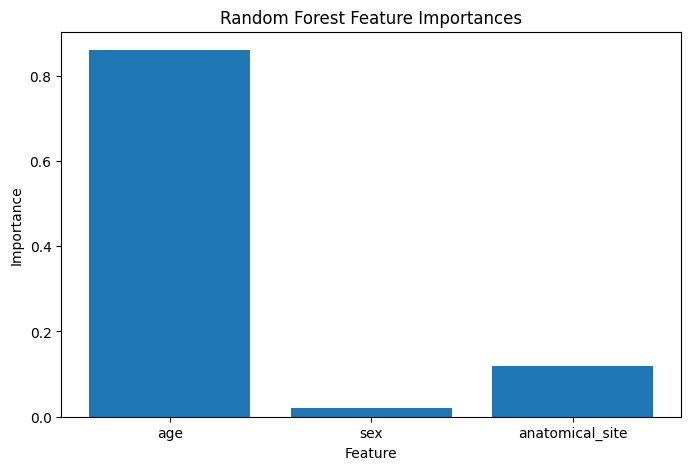


 test1 files not found.

 test2 files not found.


In [11]:
def main():
    X_raw, y, ids = load_training_data(data_dir="data")
    print("Raw training data shape:", X_raw.shape)
    print("Labels shape:", y.shape)

    X_train_raw, X_val_raw, y_train, y_val, train_ids, val_ids = make_train_val_split(
        X_raw, y, ids, test_size=0.2, random_state=42
    )

    # preprocessing
    X_train, age_median, sex_encoder, site_encoder = fit_preprocessors(X_train_raw)
    X_val = transform_with_preprocessors(X_val_raw, age_median, sex_encoder, site_encoder)
    print("Processed X_train shape:", X_train.shape)
    print("Processed X_val shape:", X_val.shape)

    # model fit
    rf, best_params, best_score = tune_random_forest(X_train, y_train)
    rf.fit(X_train, y_train)
    metrics, y_pred, y_proba = evaluate_model(rf, X_val, y_val)

    # saving results for fusion later on
    val_results = pd.DataFrame({
        "ID": val_ids,
        "true_label": y_val,
        "rf_pred": y_pred
    })
    for c in range(y_proba.shape[1]):
        val_results[f"rf_prob_{c}"] = y_proba[:, c]

    # saving results to csv (for now)
    val_results.to_csv("rf_val_predictions.csv", index=False)
    print("\nSaved validation probabilities to: rf_val_predictions.csv")

    plot_feature_importance(rf, feature_names=["age", "sex", "anatomical_site"])

    # NOTE: also unused for now
    # idea of how we could submit
    if test_files_exist(test_name="test1", data_dir="data"):
        make_submission(
            rf,
            age_median,
            sex_encoder,
            site_encoder,
            test_name="test1",
            data_dir="data",
            output_csv="rf_test1_submission.csv",
        )
    else:
        print("\n test1 files not found.")

    if test_files_exist(test_name="test2", data_dir="data"):
        make_submission(
            rf,
            age_median,
            sex_encoder,
            site_encoder,
            test_name="test2",
            data_dir="data",
            output_csv="rf_test2_submission.csv",
        )
    else:
        print("\n test2 files not found.")

if __name__ == "__main__":
    main()